In [24]:
from ultralytics import YOLO
from ultralytics.utils.plotting import Annotator

from PIL import Image
import matplotlib.pyplot as plt

import numpy as np

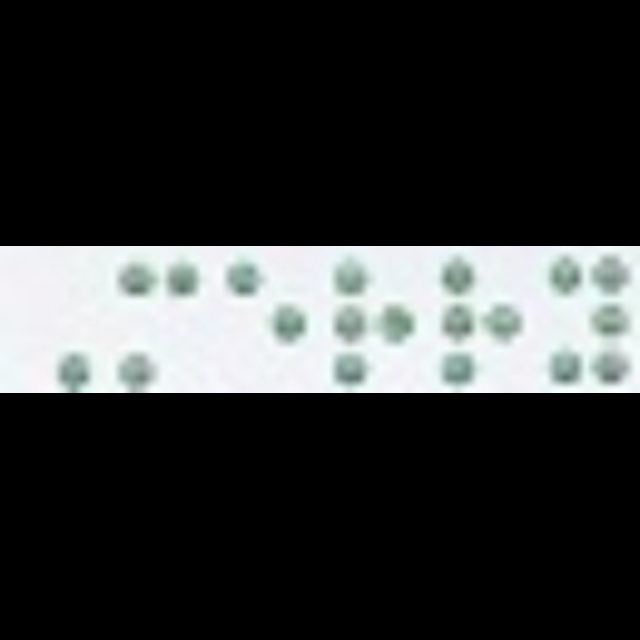

In [20]:
img = Image.open("../data/processed/test/images/104_0.jpg")
img

In [3]:
best_model: YOLO = YOLO(
    model="../models/runs/detect/train/weights/best.pt",
    task="detect"
)

best_model.info()

YOLO11n summary: 181 layers, 2,590,035 parameters, 0 gradients, 6.4 GFLOPs


(181, 2590035, 0, 6.4406016)

In [4]:
predictions = best_model.predict(img, conf=0.7)
prediction = predictions[0]

display(len(predictions), prediction)


0: 640x640 6 Characters, 5.6ms
Speed: 2.8ms preprocess, 5.6ms inference, 232.8ms postprocess per image at shape (1, 3, 640, 640)


1

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'Character'}
obb: None
orig_img: array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
orig_shape: (640, 640

In [5]:
annotator = Annotator(img)
for box, cls, conf in zip(prediction.boxes.xyxy, prediction.boxes.cls, prediction.boxes.conf):
    annotator.box_label(box, f"{best_model.names[int(cls)]} {conf:.2f}")

In [6]:
len(prediction.boxes)

6

In [7]:
img_predicted = annotator.result()

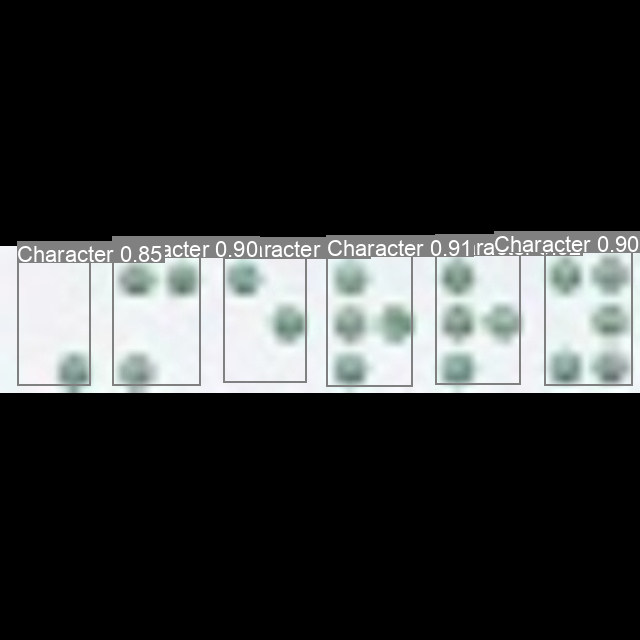

In [8]:
Image.fromarray(img_predicted)

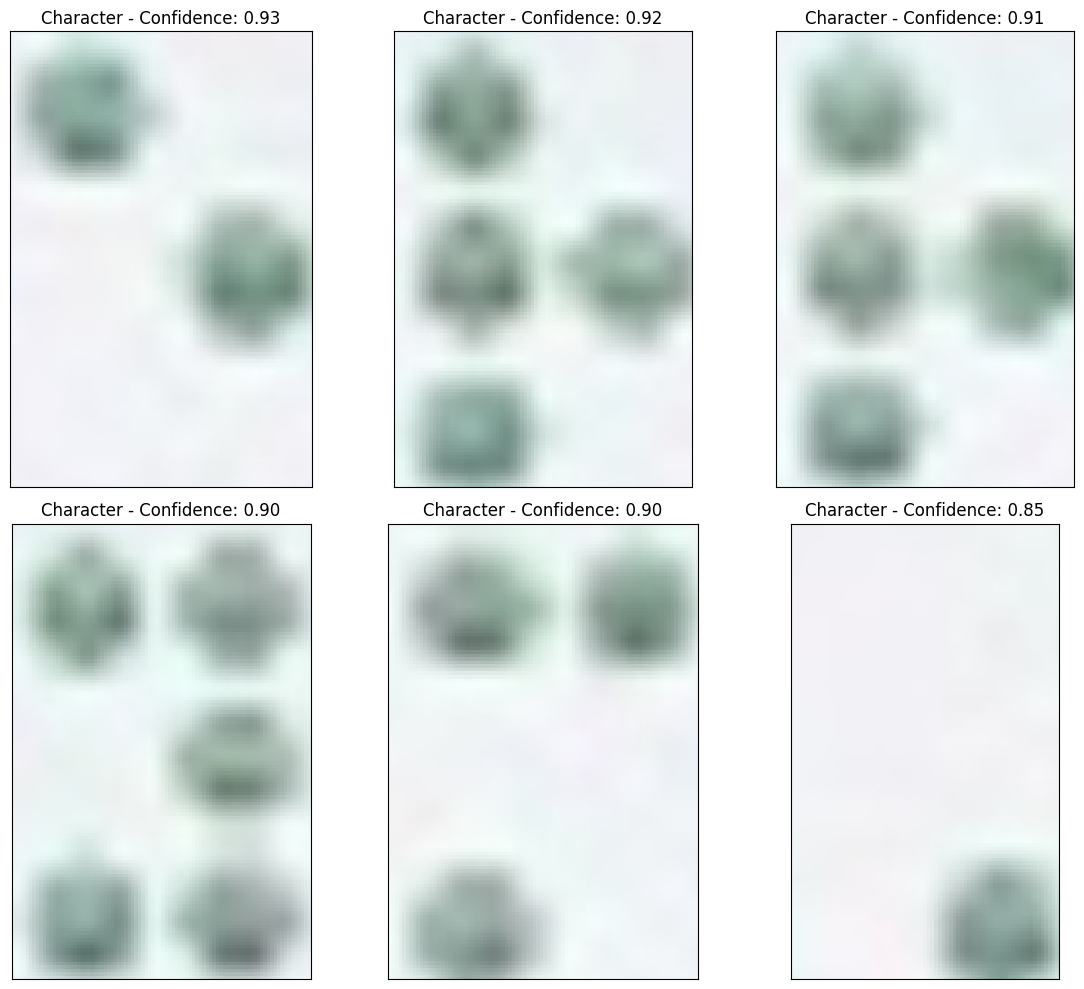

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(12, 10))
img_arr = np.array(img)

for i, ax in enumerate(axes.flatten()):
    box = prediction.boxes.xyxy[i]
    cls = prediction.boxes.cls[i]
    conf = prediction.boxes.conf[i]
    box_int = box.int().tolist()
    ax.imshow(img_arr[box_int[1]:box_int[3], box_int[0]:box_int[2]])

    ax.set_title(f"{best_model.names[int(cls)]} - Confidence: {conf:.2f}")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()